In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("C:\\Users\\LENOVO\\Desktop\\LSRA\\Data_cleaning\\kaggle_merged\\merged_music_dataset.csv")
# Define the subset of emotion classes you want to keep
selected_classes = ["anger", "fear", "romantic", "neutral", "calm"]

# Filter the DataFrame to include only those classes
df_subset = df[df["final_emotion"].isin(selected_classes)]


In [14]:
# Split the filtered data
X_train, X_test, y_train, y_test = train_test_split(
    df_subset["cleaned_lyrics"],
    df_subset["final_emotion"],
    test_size=0.2,
    random_state=42,
    stratify=df_subset["final_emotion"]
)

In [15]:
df_subset.head(2)

,track,artist,final_emotion,lyrics,cleaned_lyrics
0,'Till I Collapse,Eminem,anger,"'Cause sometimes you just feel tired, feel wea...",cause sometimes feel tired feel weak feel weak...
1,St. Anger,Metallica,anger,St. Anger 'round my neck\r\nSt. Anger 'round m...,st anger round neck st anger round neck never ...


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2), 
    min_df=3, 
    max_df=0.6,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [17]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

In [18]:
model = LinearSVC(class_weight='balanced')

In [19]:
model.fit(X_train_tfidf, y_train)
preds = model.predict(X_test_tfidf)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

       anger       0.53      0.53      0.53      1515
        calm       0.32      0.34      0.33      1018
        fear       0.43      0.43      0.43      1250
     neutral       0.25      0.24      0.25       936
    romantic       0.52      0.51      0.51      1661

    accuracy                           0.43      6380
   macro avg       0.41      0.41      0.41      6380
weighted avg       0.43      0.43      0.43      6380



              precision    recall  f1-score   support

       anger       0.53      0.53      0.53      1515
        calm       0.32      0.34      0.33      1018
        fear       0.43      0.43      0.43      1250
     neutral       0.25      0.24      0.25       936
    romantic       0.52      0.51      0.51      1661

    accuracy                           0.43      6380
   macro avg       0.41      0.41      0.41      6380
weighted avg       0.43      0.43      0.43      6380

Confusion Matrix:
 [[801 136 202 199 177]
 [ 89 346 167 152 264]
 [241 172 539 144 154]
 [188 160 172 227 189]
 [201 262 166 186 846]]


<Figure size 1200x800 with 0 Axes>

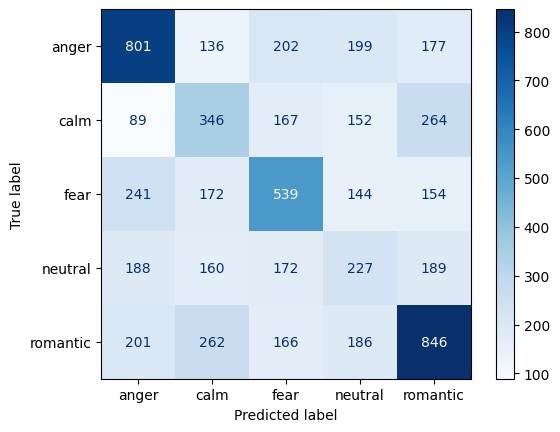

In [20]:
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
plt.figure(figsize=(12, 8))  # adjust width x height in inches

# Train model
model.fit(X_train_tfidf, y_train)

# Predict
preds = model.predict(X_test_tfidf)

# Classification report
print(classification_report(y_test, preds))

# Confusion matrix
cm = confusion_matrix(y_test, preds)
print("Confusion Matrix:\n", cm)
# Visualize confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', values_format='d')


In [21]:
# tfidf.fit(cleaned_lyrics)
print(tfidf.get_feature_names_out()[:50])


['aaah' 'abandon' 'abandoned' 'abc' 'ability' 'ablaze' 'able' 'abortion'
 'absence' 'absolute' 'absolutely' 'absolution' 'abstract' 'absurd'
 'abuse' 'abused' 'abyss' 'ac' 'accent' 'accept' 'accepted' 'access'
 'accident' 'according' 'account' 'ace' 'ache' 'achieve' 'aching' 'acid'
 'acknowledge' 'acre' 'across' 'across face' 'across floor' 'across ocean'
 'across room' 'across sea' 'across sky' 'act' 'act fool' 'act like'
 'acted' 'actin' 'actin like' 'acting' 'acting like' 'action' 'active'
 'activity']


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

# TF-IDF with optimal parameters
tfidf = TfidfVectorizer(
    max_features=10000,        # Start with 10k features
    min_df=2,                  # Ignore very rare words
    max_df=0.85,               # Ignore too common words
    ngram_range=(1, 2),        # Include unigrams and bigrams
    stop_words='english',
    sublinear_tf=True          # Use 1+log(tf)
)

X_tfidf = tfidf.fit_transform(df["cleaned_lyrics"])
y = df["final_emotion"]

In [23]:
# Select top k features using chi-squared
k = min(8000, X_tfidf.shape[1])  # Adjust based on your RAM
chi2_selector = SelectKBest(chi2, k=k)
X = chi2_selector.fit_transform(X_tfidf, y)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform
import numpy as np

# Parameter distribution for SVM
param_dist = {
    'C': loguniform(1e-2, 1e3),
    'gamma': loguniform(1e-4, 1e1),
    'kernel': ['rbf', 'linear']  # Try both
}

svm = SVC(random_state=42, class_weight='balanced')

# Randomized search with 3-fold CV
random_search = RandomizedSearchCV(
    svm, param_dist, n_iter=50, cv=3, 
    scoring='accuracy', n_jobs=-1, random_state=42
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Train with best parameters
best_svm = random_search.best_estimator_
y_pred = best_svm.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
# Final comprehensive approach
def train_optimal_svm(df):
    # Feature engineering
    tfidf = TfidfVectorizer(
        max_features=10000, min_df=2, max_df=0.85,
        ngram_range=(1, 2), sublinear_tf=True
    )
    X = tfidf.fit_transform(df["cleaned_lyrics"])
    y = df["final_emotion"]
    
    # Feature selection
    selector = SelectKBest(chi2, k=min(8000, X.shape[1]))
    X_selected = selector.fit_transform(X, y)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_selected, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Hyperparameter tuning
    param_dist = {
        'C': loguniform(1e-2, 1e3),
        'gamma': loguniform(1e-4, 1e1),
        'kernel': ['rbf', 'linear']
    }
    
    svm = SVC(class_weight='balanced', random_state=42)
    random_search = RandomizedSearchCV(
        svm, param_dist, n_iter=50, cv=3, 
        scoring='accuracy', n_jobs=-1, random_state=42
    )
    
    random_search.fit(X_train, y_train)
    
    # Final evaluation
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    print(f"Best Parameters: {random_search.best_params_}")
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nDetailed Report:")
    print(classification_report(y_test, y_pred))
    
    return best_model, tfidf, selector

# Run the complete pipeline
best_model, tfidf, selector = train_optimal_svm(df)

In [ ]:
import psutil
import os

def check_memory():
    process = psutil.Process(os.getpid())
    memory_gb = process.memory_info().rss / 1024 / 1024 / 1024
    print(f"Memory usage: {memory_gb:.2f} GB")
    return memory_gb

# Check before major operations
check_memory()

Memory usage: 0.52 GB


0.5174446105957031